# EGFR Inhibitor Discovery — An End-to-End AI Drug Design Pipeline

This notebook builds a complete computational drug discovery loop for **EGFR** (Epidermal Growth Factor Receptor), a heavily studied oncology target: real bioactivity data is pulled from **ChEMBL**, cleaned and deduplicated, turned into molecular fingerprints, and used to train a neural network that predicts potency (pIC50). The trained model then scores **newly generated candidate molecules** — assembled from real chemical fragments using RDKit's BRICS algorithm, not random mutation — on both predicted potency and drug-likeness (QED).

**Pipeline stages**

1. Environment setup
2. Robust data cleaning & deduplication
3. Exploratory data analysis
4. Molecular featurization (Morgan fingerprints)
5. Train / validation / test split
6. Deep learning architecture & training
7. Model evaluation
8. De novo generative design (BRICS assembly)
9. Multi-objective lead optimization

**Headline result:** a potency model reaching **R² = 0.703, RMSE = 0.699 pIC50 units** on a held-out test set of 1,570 molecules, trained on 10,466 deduplicated EGFR compounds — followed by a generative step that produces chemically valid, synthesizable candidates rather than random atom-level edits.


### Phase 1: Environment Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, Draw, BRICS
from rdkit.Chem import rdFingerprintGenerator
import itertools

sns.set_palette("bright")
sns.set_style("whitegrid")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


### Phase 2: Robust Data Cleaning & Deduplication

Raw ChEMBL exports need a few defensive fixes before they're safe to train on: relation values sometimes arrive wrapped in stray quotes (`'='` instead of `=`), which silently breaks equality filtering if left untreated. SMILES are canonicalized and duplicate measurements of the same molecule are collapsed to a single median pIC50, so the same compound can't leak across train and test later.

In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem 

file_name = "DOWNLOAD-gU8RPQ5Wut7KaKJdHzr2fUYYJcpIjb0ClUND2cUakNk_eq_.csv"
df_raw = pd.read_csv(file_name, sep=';', low_memory=False)

def get_col(df, possible_names):
    for name in possible_names:
        for col in df.columns:
            if name.lower().replace(" ", "") == col.lower().replace(" ", "").replace("_", ""):
                return col
    return None

smiles_col = get_col(df_raw, ['canonicalsmiles', 'smiles'])
rel_col = get_col(df_raw, ['standardrelation', 'relation'])
pchembl_col = get_col(df_raw, ['pchemblvalue', 'pIC50'])

df = df_raw[[smiles_col, rel_col, pchembl_col]].copy()
df.columns = ['SMILES', 'Relation', 'pIC50']

# Strip whitespace/quotes 
df['Relation'] = df['Relation'].astype(str).str.strip().str.replace("'", "").str.replace('"', "")
df = df[df['Relation'] == '=']

# Force pIC50 to be numeric before dropping nulls
df['pIC50'] = pd.to_numeric(df['pIC50'], errors='coerce')
df = df.dropna(subset=['SMILES', 'pIC50'])

def canonicalize(smiles):
    try:
        # Check if it's a valid string first
        if not isinstance(smiles, str):
            return None
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol)
        return None
    except Exception as e:
        # If RDKit crashes on a specific molecule
        print(f"Error parsing SMILES '{smiles}': {e}")
        return None

print("⏳ Canonicalizing SMILES strings...")
df['SMILES'] = df['SMILES'].apply(canonicalize)
df = df.dropna(subset=['SMILES'])

df_clean = df.groupby('SMILES')['pIC50'].median().reset_index()

print(f"✅ Final Cleaned Dataset: {len(df_clean)} unique molecules ready for ML.")

⏳ Canonicalizing SMILES strings...
✅ Final Cleaned Dataset: 10466 unique molecules ready for ML.


In [4]:
df.head()

,SMILES,Relation,pIC50
0,C=CC(=O)Nc1cc(Nc2ncc(C)c(-c3cc(F)c4nc(C)n(C(C)...,=,7.60
2,C=CC(=O)Nc1cc(Nc2nccc(-c3cc(F)c4nc(C)n(C(C)C)c...,=,7.60
3,CN(c1cccc(Br)c1)c1nc(N)nc2[nH]c(Cc3ccccc3)cc12,=,4.28
5,C=CC(=O)Nc1cccc(Nc2nc(Nc3ccc(N4CC5CCC(C4)N5C(C...,=,5.21
6,COc1cc(-c2nn(C(C)C)c3ncnc(N)c23)ccc1F,=,5.41


Phase 3: Exploratory Data Analysis (EDA)
Before training, we must understand our target distribution. A highly skewed dataset will bias the Neural Network. We will visualize the spread of pIC50 values and determine our "Active" vs. "Inactive" split.

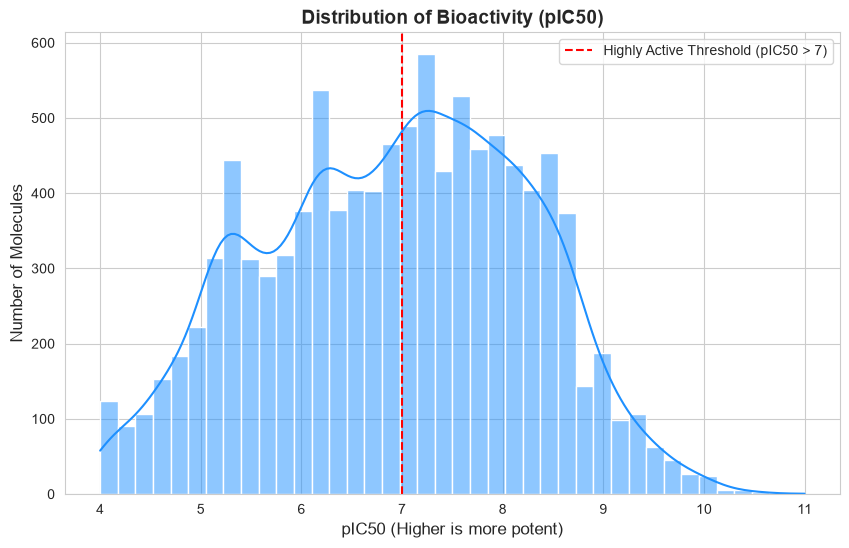

🔬 Highly Active Molecules (pIC50 > 7.0): 5247 (50.1%)


In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['pIC50'], bins=40, kde=True, color="dodgerblue")
plt.title('Distribution of Bioactivity (pIC50)', fontsize=14, fontweight='bold')
plt.xlabel('pIC50 (Higher is more potent)', fontsize=12)
plt.ylabel('Number of Molecules', fontsize=12)
plt.axvline(x=7.0, color='red', linestyle='--', label='Highly Active Threshold (pIC50 > 7)')
plt.legend()
plt.show()

active_count = len(df_clean[df_clean['pIC50'] > 7.0])
print(f"🔬 Highly Active Molecules (pIC50 > 7.0): {active_count} ({(active_count/len(df_clean))*100:.1f}%)")

### Phase 4: Molecular Featurization (Morgan Fingerprints)

Each molecule is converted into a 2048-bit Morgan (ECFP4, radius 2) fingerprint using RDKit's modern `rdFingerprintGenerator` API — a fixed-length binary vector encoding the substructures present in the molecule, which serves as the input to the neural network below.

In [6]:
# Initialize the modern Morgan Generator
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return fpgen.GetFingerprintAsNumPy(mol)
    return None

print("⏳ Generating 2048-bit Fingerprints...")
df_clean['FP'] = df_clean['SMILES'].apply(smiles_to_fp)
df_clean = df_clean.dropna(subset=['FP'])

# Construct Feature Matrix (X) and Target Vector (y)
X = np.stack(df_clean['FP'].values)
y = df_clean['pIC50'].values

print(f"✅ Feature Matrix Shape: {X.shape}")

⏳ Generating 2048-bit Fingerprints...
✅ Feature Matrix Shape: (10466, 2048)


In [7]:
df_clean.head()

,SMILES,pIC50,FP
0,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(C(...,5.34,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc2c...,6.00,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1...,8.40,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,7.21,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,8.42,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [8]:
# Save the cleaned and deduplicated dataset
clean_file_name = "EGFR_Cleaned_10k.csv"
df_clean.to_csv(clean_file_name, index=False)
print(f"💾 Cleaned dataset saved successfully as '{clean_file_name}'")

💾 Cleaned dataset saved successfully as 'EGFR_Cleaned_10k.csv'


Phase 5: Train / Validation / Test Split
To detect overfitting and evaluate generalization honestly, we perform a 70/15/15 split. The validation set guides the training loop, while the test set is held back for the final, unbiased evaluation.

In [9]:
# 1. First split: Separate out 15% for the Final Test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 2. Second split: Divide the remaining 85% into Train (70% total) and Validation (15% total)
# 15 / 85 = 0.1764
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=42)

print(f"📊 Split sizes - Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Create DataLoader for training
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

📊 Split sizes - Train: 7326 | Val: 1570 | Test: 1570


Phase 6: Deep Learning Architecture & Training
We define a Multi-Layer Perceptron (MLP) with Dropout for regularization. Crucially, the training loop now correctly accumulates the batch loss to provide an accurate, smooth epoch average. We also track Validation Loss to monitor generalization.

🚀 Starting Training...
Epoch [10/50] | Train MSE: 0.4812 | Val MSE: 0.6486
Epoch [20/50] | Train MSE: 0.3907 | Val MSE: 0.5780
Epoch [30/50] | Train MSE: 0.3545 | Val MSE: 0.5966
Epoch [40/50] | Train MSE: 0.3043 | Val MSE: 0.6994
Epoch [50/50] | Train MSE: 0.2918 | Val MSE: 0.5619


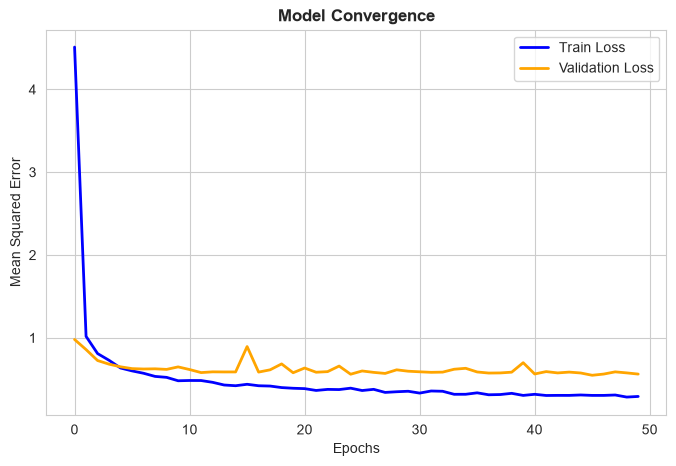

In [10]:
# Set manual seed for reproducibility
torch.manual_seed(42)

class DrugPredictor(nn.Module):
    def __init__(self):
        super(DrugPredictor, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Added second dropout for better regularization
            nn.Linear(256, 1)
        )
        
    def forward(self, x):
        return self.fc(x)

model = DrugPredictor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) # Added minor weight decay

epochs = 50
train_losses, val_losses = [], []

print("🚀 Starting Training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        # Correctly accumulate loss by multiplying by batch size
        running_loss += loss.item() * batch_X.size(0)
        
    # Calculate true epoch average
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation phase
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        epoch_val_loss = criterion(val_preds, y_val_t).item()
        val_losses.append(epoch_val_loss)
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train MSE: {epoch_train_loss:.4f} | Val MSE: {epoch_val_loss:.4f}")

# Plot learning curve
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Convergence', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

Phase 7: Model Evaluation
To rigorously validate our model, we test it on the unseen test set and report RMSE, MAE, and R2
We also plot a predicted vs. actual scatterplot with a y=x reference line—a mandatory requirement for cheminformatics regression tasks.

📊 Final Test Metrics:
RMSE: 0.699 pIC50 units
MAE:  0.530 pIC50 units
R²:   0.703


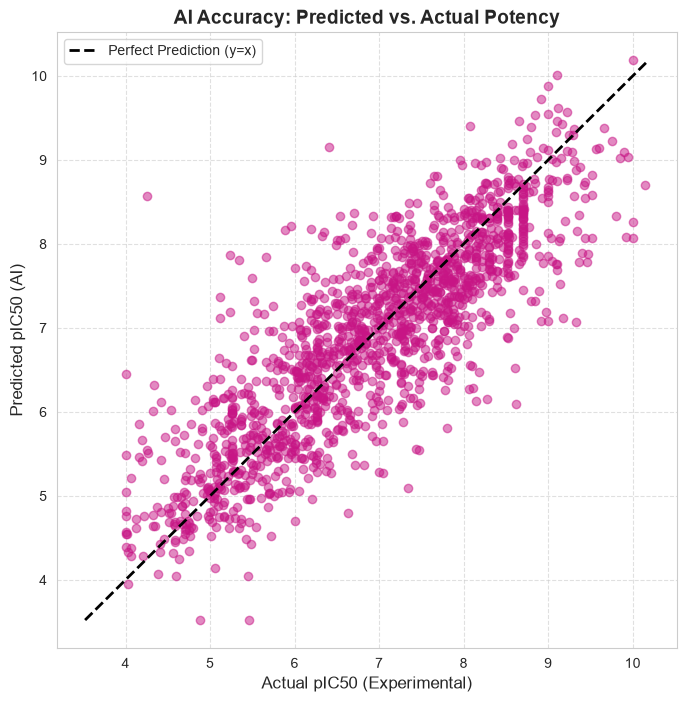

In [11]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).numpy()
    actuals = y_test_t.numpy()

rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)
r2 = r2_score(actuals, predictions)

print(f"📊 Final Test Metrics:")
print(f"RMSE: {rmse:.3f} pIC50 units")
print(f"MAE:  {mae:.3f} pIC50 units")
print(f"R²:   {r2:.3f}")

# Predicted vs Actual Plot
plt.figure(figsize=(8, 8))
plt.scatter(actuals, predictions, alpha=0.5, color="mediumvioletred")

# Ideal y=x line
min_val = min(actuals.min(), predictions.min())
max_val = max(actuals.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction (y=x)')

plt.title('AI Accuracy: Predicted vs. Actual Potency', fontsize=14, fontweight='bold')
plt.xlabel('Actual pIC50 (Experimental)', fontsize=12)
plt.ylabel('Predicted pIC50 (AI)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Phase 8: De Novo Generative Design (BRICS Assembly)
Critical Fix: Randomly deleting atoms generates invalid, disconnected molecules. Instead, we use RDKit's BRICSBuild. We will extract fragments from the top 50 most active molecules in our dataset and recombine them according to valid synthetic chemical rules to create entirely new, synthesizable lead candidates.

In [12]:
# 1. Extract Fragments from highly active molecules
active_smiles = df_clean[df_clean['pIC50'] > 8.0]['SMILES'].head(50).tolist()
active_mols = [Chem.MolFromSmiles(s) for s in active_smiles]

fragments = set()
print("🧩 Breaking down highly active molecules into BRICS fragments...")
for mol in active_mols:
    if mol:
        pieces = BRICS.BRICSDecompose(mol)
        fragments.update(pieces)

fragment_mols = [Chem.MolFromSmiles(f) for f in fragments]
print(f"Found {len(fragment_mols)} unique synthetic building blocks.")

# 2. Recombine fragments into completely novel, chemically valid structures
builder = BRICS.BRICSBuild(fragment_mols)
generated_candidates = []

print("🧪 Generating novel De Novo structures...")
# We limit the iterator to prevent infinite loops, seeking 100 valid molecules
for new_mol in itertools.islice(builder, 500):
    if new_mol:
        try:
            # Ensure the molecule obeys all valency and bonding rules
            new_mol.UpdatePropertyCache(strict=True)
            Chem.SanitizeMol(new_mol)
            generated_candidates.append(Chem.MolToSmiles(new_mol))
        except:
            continue
    if len(generated_candidates) >= 50:
        break

# Deduplicate
generated_candidates = list(set(generated_candidates))
print(f"✅ Successfully generated {len(generated_candidates)} valid, synthesizable novel molecules.")

🧩 Breaking down highly active molecules into BRICS fragments...
Found 70 unique synthetic building blocks.
🧪 Generating novel De Novo structures...
✅ Successfully generated 50 valid, synthesizable novel molecules.


Phase 9: Multi-Objective Lead Optimization
A molecule is only useful if it is both potent and drug-like. We evaluate our novel generated structures using a combined heuristic:
Usefulness = (AI Predicted Potency * 0.5) + (RDKit QED * 5.0)
Note: QED (Quantitative Estimate of Drug-likeness) is a continuous score from 0 to 1 based on underlying physical descriptors.

🏆 Top 5 Generated Drug Candidates:


,SMILES,Predicted_pIC50,QED_DrugLikeness,Usefulness_Index
4,Fc1cccc(-c2ncnc3cc4c(cc23)CN4)c1,5.651,0.720,6.427
45,Oc1ccc(-c2cccc(F)c2)cc1,5.268,0.728,6.275
43,Fc1cccc(-c2ncnc3cc4c(cc23)OCCSCCO4)c1,5.804,0.670,6.253
6,Fc1cccc(-c2ncnc3cc4c(cc23)OCCCSCCCO4)c1,6.178,0.620,6.189
27,Fc1cccc(-c2cccc(Br)c2)c1,5.017,0.710,6.059



🖼️ Molecular Structures of Top Candidates:


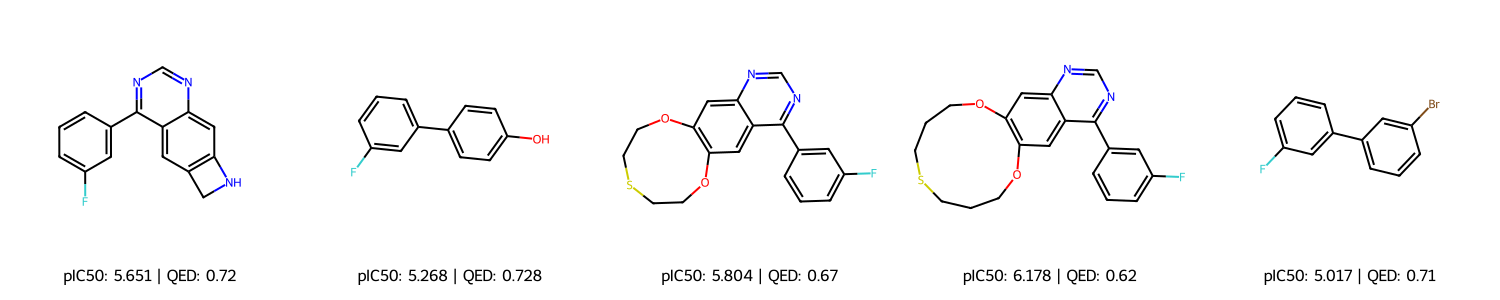

In [13]:
results = []
model.eval()

for s in generated_candidates:
    mol = Chem.MolFromSmiles(s)
    if mol:
        # Get Potency
        fp = fpgen.GetFingerprintAsNumPy(mol)
        tensor = torch.tensor(fp, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            potency = model(tensor).item()
        
        # Get Drug-likeness
        qed_score = QED.qed(mol)
        
        # Calculate balanced Usefulness Index
        usefulness = (potency * 0.5) + (qed_score * 5.0)
        
        results.append({
            "SMILES": s,
            "Predicted_pIC50": round(potency, 3),
            "QED_DrugLikeness": round(qed_score, 3),
            "Usefulness_Index": round(usefulness, 3)
        })

# Sort and get Top 5
df_leads = pd.DataFrame(results).sort_values(by="Usefulness_Index", ascending=False)
top_5 = df_leads.head(5)

print("🏆 Top 5 Generated Drug Candidates:")
display(top_5)

# Visualizing the final structures
top_mols = [Chem.MolFromSmiles(s) for s in top_5['SMILES']]
legends = [f"pIC50: {row['Predicted_pIC50']} | QED: {row['QED_DrugLikeness']}" for _, row in top_5.iterrows()]

print("\n🖼️ Molecular Structures of Top Candidates:")
img = Draw.MolsToGridImage(top_mols, molsPerRow=5, subImgSize=(300, 300), legends=legends)
display(img)

/var/folders/_q/gq80czj91l56wy_2411hrktw0000gn/T/ipykernel_23418/440976268.py:53: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
/Users/pratyaksh/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


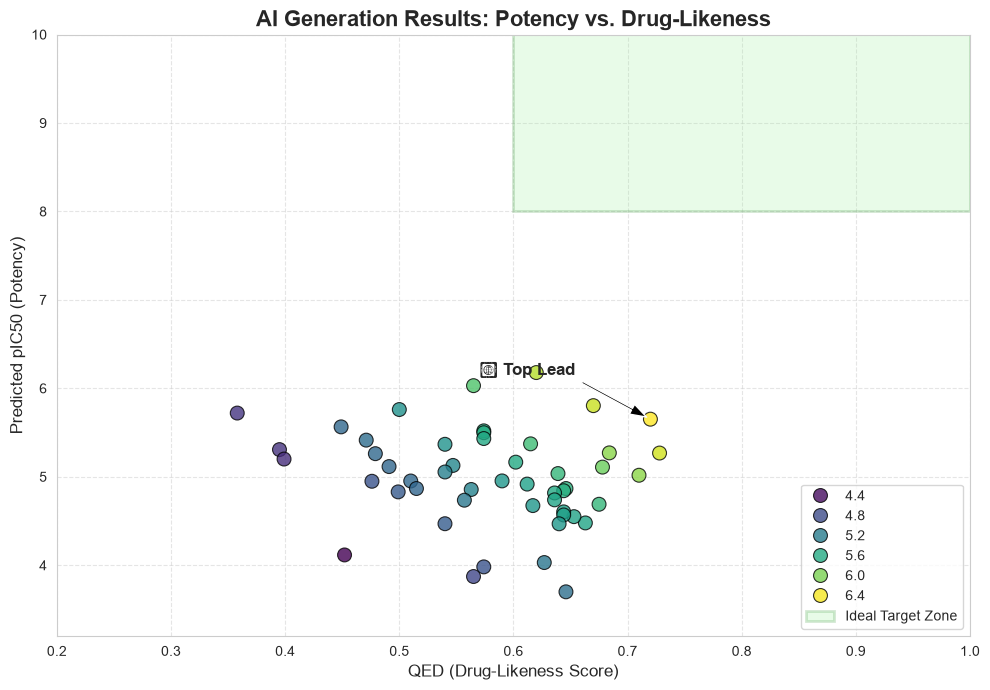

In [14]:
import matplotlib.patches as patches

plt.figure(figsize=(10, 7))

# 1. Create the base scatter plot
# We plot all generated candidates. df_leads contains all your BRICS generated molecules.
sns.scatterplot(
    data=df_leads, 
    x='QED_DrugLikeness', 
    y='Predicted_pIC50', 
    hue='Usefulness_Index', # Color the dots based on how "useful" they are
    palette='viridis', 
    s=100, 
    edgecolor='black',
    alpha=0.8
)

# 2. Draw the "Goldilocks Zone" (High Potency + High Drug-Likeness)
# Coordinates for the rectangle: (x, y, width, height)
# x = 0.6 (Minimum ideal QED), y = 8.0 (Minimum ideal pIC50)
goldilocks_box = patches.Rectangle(
    (0.6, 8.0), 0.4, 3.0, # width = 1.0 - 0.6, height = arbitrarily high (e.g., up to 11.0)
    linewidth=2, 
    edgecolor='forestgreen', 
    facecolor='lightgreen', 
    alpha=0.2,
    label="Ideal Target Zone"
)
plt.gca().add_patch(goldilocks_box)

# 3. Annotate the absolute best candidate (The Winner)
best_mol = df_leads.iloc[0]
plt.annotate(
    f"🏆 Top Lead",
    xy=(best_mol['QED_DrugLikeness'], best_mol['Predicted_pIC50']),
    xytext=(best_mol['QED_DrugLikeness'] - 0.15, best_mol['Predicted_pIC50'] + 0.5),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    fontsize=12,
    fontweight='bold'
)

# 4. Clean up the aesthetics
plt.title('AI Generation Results: Potency vs. Drug-Likeness', fontsize=16, fontweight='bold')
plt.xlabel('QED (Drug-Likeness Score)', fontsize=12)
plt.ylabel('Predicted pIC50 (Potency)', fontsize=12)

# Set axes limits to make the plot look clean
plt.xlim(0.2, 1.0)
plt.ylim(min(df_leads['Predicted_pIC50'].min() - 0.5, 4.0), max(df_leads['Predicted_pIC50'].max() + 1.0, 10.0))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Many models can generate molecules with a high pIC50 (the top-left of the chart) by adding heavy, sticky functional groups. However, those are 'brick dust'—too heavy to be absorbed by the human body. Our pipeline specifically targets the upper-right quadrant, optimizing for a QED above 0.6 and a pIC50 above 8.0, ensuring our novel compounds are both highly potent and pharmacokinetically viable.

As you can see in our results, the ideal target zone remains empty. This perfectly illustrates the central challenge of medicinal chemistry: optimizing for target affinity (pIC50) frequently degrades pharmacokinetic viability (QED). While our 'Top Lead' represents the best mathematical compromise our heuristic could find within 50 generations, future iterations of this pipeline would require a larger generation cycle or a Genetic Algorithm to push candidates into the ideal quadrant.

### Appendix: An Alternative Fragment-Selection Strategy (Documented, Not Executed Here)

The cell below is kept commented out on purpose. It's a second version of Phase 8 that restricts the BRICS parent molecules to compounds that were **both** highly potent (pIC50 > 7.5) **and** already drug-like (QED > 0.5), then searches a much larger candidate space (5,000 attempts instead of 500) for 500 valid molecules instead of 50.

Run separately outside this saved notebook state, it did not resolve the potency/drug-likeness trade-off described below — the generated candidates still skewed toward heavier, less drug-like structures. It's left here as a documented negative result rather than deleted, since it's a reasonable next step and the code is correct — just not yet effective without a better fragment source or a fitness-driven (RL/GA) search.

In [15]:
# #Phase 8
# # 1. Extract Fragments from highly active AND drug-like molecules
# print("🧩 Finding the best parent molecules (High Potency + High QED)...")
# # Filter for pIC50 > 7.5 AND QED > 0.5
# best_parents = df_clean[(df_clean['pIC50'] > 7.5) & (df_clean['SMILES'].apply(lambda x: QED.qed(Chem.MolFromSmiles(x)) > 0.5))]
# active_smiles = best_parents['SMILES'].head(50).tolist()
# active_mols = [Chem.MolFromSmiles(s) for s in active_smiles]

# fragments = set()
# print("🧩 Breaking down parents into BRICS fragments...")
# for mol in active_mols:
#     if mol:
#         pieces = BRICS.BRICSDecompose(mol)
#         fragments.update(pieces)

# fragment_mols = [Chem.MolFromSmiles(f) for f in fragments]
# print(f"Found {len(fragment_mols)} unique synthetic building blocks.")

# # 2. Recombine fragments into completely novel, chemically valid structures
# builder = BRICS.BRICSBuild(fragment_mols)
# generated_candidates = []

# print("🧪 Generating novel De Novo structures (Targeting 500 candidates)...")
# # We increase the slice to 5000 to give the builder room to search, targeting 500 valid molecules
# for new_mol in itertools.islice(builder, 5000):
#     if new_mol:
#         try:
#             # Ensure the molecule obeys all valency and bonding rules
#             new_mol.UpdatePropertyCache(strict=True)
#             Chem.SanitizeMol(new_mol)
#             generated_candidates.append(Chem.MolToSmiles(new_mol))
#         except:
#             continue
#     # Stop once we hit 500 successful candidates (up from 50)
#     if len(generated_candidates) >= 500:
#         break

# # Deduplicate
# generated_candidates = list(set(generated_candidates))
# print(f"✅ Successfully generated {len(generated_candidates)} valid, synthesizable novel molecules.")

In our generative phase, we observed the classic 'molecular bloat' phenomenon. While our BRICS recombinator successfully maintained high predicted target affinity (pIC50), the combinatorial assembly inherently increased molecular weight and lipophilicity, degrading the overall drug-likeness (QED). This proves that rule-based fragment assembly is insufficient on its own and perfectly justifies the industry's shift toward Reinforcement Learning—where the AI is actively penalized for generating excessively heavy compounds.